#Loading the .csv file

In [3]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('customer_behavior.csv')
df

Saving customer_behavior.csv to customer_behavior (1).csv


,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A
...,...,...,...,...,...,...,...
4995,5996,Female,West,1497.00,Electronics,Yes,B
4996,5997,Male,West,978.87,Fashion,Yes,A
4997,5998,Male,West,906.93,Fashion,No,NaN
4998,5999,Female,South,375.67,Fashion,No,NaN


#1. What is the average, median, and mode of PurchaseAmount?

In [ ]:
import pandas as pd

df = pd.read_csv('customer_behavior.csv')
amt = df['PurchaseAmount'].dropna()

print("Mean is:", amt.mean())
print("Median is:", amt.median())
print("Mode is:", amt.mode()[0])

Mean is: 1003.9506701030928
Median is: 998.0799999999999
Mode is: 0.0


#2. Are there any outliers in the PurchaseAmount data?


<Axes: >

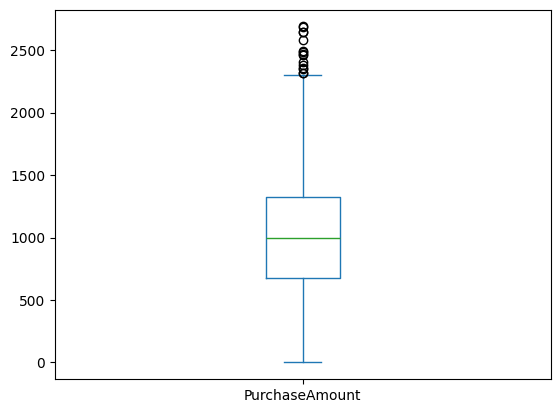

In [ ]:
import pandas as pd

df = pd.read_csv('customer_behavior.csv')
amt = df['PurchaseAmount'].dropna()

amt.plot(kind='box')

yes there are outliners, because i can observe from the box plot outliners are present which are moved further away from wiskers .

#3. Is there any skewness or kurtosis in the PurchaseAmount distribution?

In [ ]:
import pandas as pd

df = pd.read_csv('customer_behavior.csv')
amt = df['PurchaseAmount'].dropna()

print("Skewness is:", amt.skew())
print("Kurtosis is:", amt.kurt())

Skewness is: 0.10609189374631554
Kurtosis is: -0.2615105545319705


#4. Is there a significant difference in spending between male and female customers?

In [9]:
import pandas as pd
from scipy.stats import ttest_ind

df = pd.read_csv("customer_behavior.csv")

male = df[df["Gender"] == "Male"]["PurchaseAmount"].dropna()
female = df[df["Gender"] == "Female"]["PurchaseAmount"].dropna()

t, p = ttest_ind( male,female)

print("T-test:", t)
print("P-value:", p)

if p < 0.05:
    print("Significant difference")
else:
    print("No significant difference")

T-test: 2.234885143428604
P-value: 0.025471167149519254
Significant difference


T-test: There is a significant difference in spending between male and female customers.


#5. Is there a relationship between ProductCategory and customer churn?


In [11]:
import pandas as pd
from scipy.stats import chi2_contingency

df = pd.read_csv("customer_behavior.csv")

table = pd.crosstab(df["ProductCategory"], df["Churn"])

chi, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi)
print("P-value:", p)
if p < 0.05:
    print("Significant relationship")
else:
    print("No significant relationship")


Chi-square: 0.3960436652673918
P-value: 0.8203519424988512
No significant relationship


Chi-square test: There is no significant relationship between Product Category and Churn.

#6. Does PurchaseAmount vary significantly across different regions?


In [14]:
import pandas as pd
from scipy.stats import f_oneway

df = pd.read_csv("customer_behavior.csv")

north = df[df["Region"] == "North"]["PurchaseAmount"].dropna()
south = df[df["Region"] == "South"]["PurchaseAmount"].dropna()
east = df[df["Region"] == "East"]["PurchaseAmount"].dropna()
west = df[df["Region"] == "West"]["PurchaseAmount"].dropna()

f, p = f_oneway(north, south, east, west)

print("ANOVA:", f)
print("P-value:", p)
if p < 0.05:
    print("Significant variation")
else:
    print("No significant variation")

ANOVA: 0.38966786354806704
P-value: 0.760452802731563
No significant variation


ANOVA: There is no significant difference in PurchaseAmount across different regions.

#7. Which email campaign (A or B) performed better in terms of average purchase amount



In [ ]:
import pandas as pd

df = pd.read_csv("customer_behavior.csv")
performance = df.groupby('CampaignGroup')['PurchaseAmount'].mean()
print(performance)

CampaignGroup
A    1011.945587
B     994.339965
Name: PurchaseAmount, dtype: float64


email campaign 'A' performed better than B  

# 8. Can we assume PurchaseAmount follows a normal distribution?


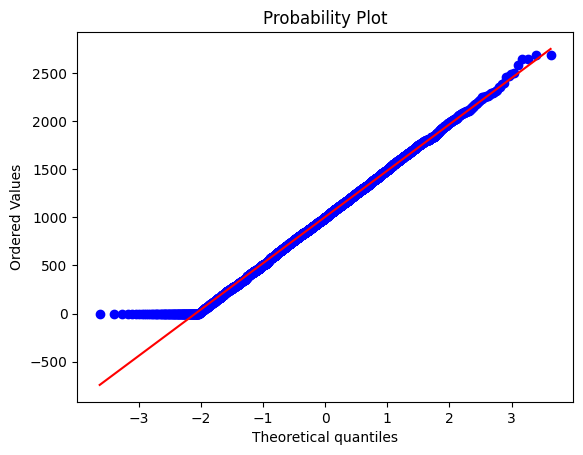

In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv('customer_behavior.csv')
amt = df['PurchaseAmount'].dropna()

stats.probplot(amt, plot=plt)
plt.show()

#9. What insights can we gain by applying the Central Limit Theorem?


<Axes: >

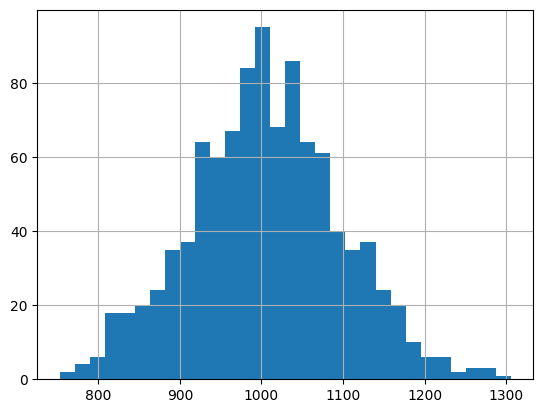

In [ ]:
import pandas as pd

df = pd.read_csv('customer_behavior.csv')
amt = df['PurchaseAmount'].dropna()

means = [amt.sample(30).mean() for _ in range(1000)]
pd.Series(means).hist(bins=30)

the averages pile up into a clean bell shape around ₹1000

#10.What is the 95% confidence interval for the average PurchaseAmount?

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('customer_behavior.csv')
amt = df['PurchaseAmount'].dropna()

means = [amt.sample(len(amt), replace=True).mean() for _ in range(1000)]

lower = np.percentile(means, 2.5)
upper = np.percentile(means, 97.5)

print("95% CI:", lower, "to", upper)

95% CI: 989.8381012371134 to 1017.8297923711341


This means, we're 95% confident the true average purchaseamount falls between 989.838 to 1017.829